In [1]:
import numpy as np
import time
import mpmath as mp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
mp.mp.dps = 50

In [22]:
def iszero(a, eps=1e-6):
    if np.abs(a) < eps:
        return True
    return False

def inv_cdf(a, v):
    if iszero(a):
        return v
    return 1/a*(a/2-1+np.sqrt(2*a*v + (a/2-1)**2))

def inv_cdf_deriv(a, v):
    if iszero(a):
        return -1/8*(2*v-1)**2 + 1/8
    temp = np.sqrt(2*a*v + (a/2-1)**2)
    return 1/a**2 * (1. - temp) + 1/2/a / temp * (2*v + a/2 - 1)

def inv_cdf_numerical_deriv(a, v, eps=1e-3):
    # if iszero(a):
    #     return np.zeros_like(v)
    return (inv_cdf(a+eps, v) - inv_cdf(a-eps, v)) / 2 / eps

def get_m1_k(a, k, n):
    if iszero(a):
        return k/(n+1)
    b = (0.5*a-1)**2
    return float(0.5 - 1/a + np.sqrt(b) / a * mp.hyp2f1(-0.5, k, n+1, -2*a/b))

def get_m2(a):
    return (a+4)/12

def expected_wasserstein_loss_affine(a1, a2, n, m1_a1=None, m1_a2=None):
    if m1_a1 is None:
        m1_a1 = np.array([get_m1_k(a1, k+1, n) for k in range(n)])
    if m1_a2 is None:
        m1_a2 = np.array([get_m1_k(a2, k+1, n) for k in range(n)])
    dist = -2*np.mean(m1_a1*m1_a2) + get_m2(a1) + get_m2(a2)
    return dist

In [24]:
def numerical_sol_expected_loss(a1: float,
                         n:  int,
                        m1_a1 = None,
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500):
    """
    Find a2* that minimises   expected_wasserstein_loss_affine_emp_conti(a1, a2, n).

    Parameters
    ----------
    a1, n       : parameters forwarded to expected_wasserstein_loss_affine_emp_conti
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a2):
        return float(expected_wasserstein_loss_affine(a1, a2, n, m1_a1=m1_a1))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2, 2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [107]:
def sqW2loss_affine(a, gen_v, target_sample):
    target_sample_sorted = np.sort(target_sample)
    gen_sample = inv_cdf(a, gen_v)
    gen_sample_sorted = np.sort(gen_sample)
    return np.mean((gen_sample_sorted - target_sample_sorted)**2)

def sqW2loss_affine_numerical_deriv(a, gen_v, target_sample, eps=1e-3):
    return (sqW2loss_affine(a+eps, gen_v, target_sample) - sqW2loss_affine(a-eps, gen_v, target_sample)) / 2 / eps

def stochastic_gradient_sqW2loss_affine(a, gen_sample, gen_v, target_sample):
    target_sample_sorted = np.sort(target_sample)
    idx = np.argsort(gen_sample)
    gen_sample_sorted = gen_sample[idx]
    gen_v_sorted = gen_v[idx]
    grad_a = 2 * np.mean((gen_sample_sorted - target_sample_sorted) * inv_cdf_deriv(a, gen_v_sorted))
    return grad_a

def robbins_monro_steps(i, eta0, gamma):
    return eta0 / (1. + gamma*float(i))

def sgd_empirical_sqW2loss_affine(a0, true_a, sample_size, n_iter, eta0, gamma):
    a = np.array(a0)
    a_trj = []
    a_trj.append(np.array(a))
    for i in range(n_iter):
        # Target sample
        u_target = np.random.rand(sample_size)
        target_sample = inv_cdf(true_a, u_target)
        # Generator sample with current a
        u_gen = np.random.rand(sample_size)
        gen_sample = inv_cdf(a, u_gen)
        grad = stochastic_gradient_sqW2loss_affine(a, gen_sample, u_gen, target_sample)
        stepsize = robbins_monro_steps(i, eta0, gamma)
        a -= stepsize * grad
        # print(grad, a)
        # constraint on a
        if a > 2:
            a = 2
        elif a < -2:
            a = -2
        a_trj.append(np.array(a))
    a_trj = np.array(a_trj)
    return a_trj


In [139]:
np.random.seed(0)
true_a = np.array(1.5)
a0 = np.array(0.75)
# n_iter, eta0, gamma = 10000, 1.0, 0.005
n_iter, eta0, gamma = 10000, 1.0, 0.01
# sample_size_set = [6]
sample_size_set = [6, 10, 20, 50, 100]
# sample_size_set = [100]
a_trj_set = {}
a_emp_sol_set = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    a_trj = sgd_empirical_sqW2loss_affine(a0, true_a, sample_size, n_iter, eta0, gamma)
    m1_a1 = np.array([get_m1_k(true_a, k+1, sample_size) for k in range(sample_size)])
    a_emp_sol, objfun_sol = numerical_sol_expected_loss(true_a, sample_size, m1_a1)
    a_trj_set[str(sample_size)] = a_trj
    a_emp_sol_set[str(sample_size)] = a_emp_sol

0 6
1 10
2 20
3 50
4 100


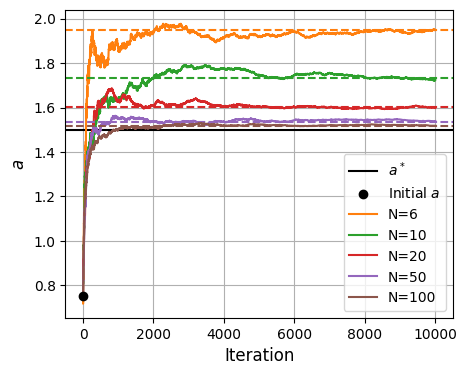

In [143]:
plt.figure(figsize=(5,4))
plt.axhline(true_a, color='k', linestyle='-', label=fr'$a^*$')
plt.scatter(0, a0, marker='o', c='k', label=r'Initial $a$', zorder=100)
plt.plot(0, a0)
for j, sample_size in enumerate(sample_size_set):
    a_trj = a_trj_set[str(sample_size)]
    a_emp_sol = a_emp_sol_set[str(sample_size)]
    plt.plot(a_trj, label=fr'N={sample_size}')
    plt.axhline(a_emp_sol, color=plt.gca().lines[-1].get_color(), linestyle='--')#, label=fr'$\hat\a_{i+1}$ (N={sample_size})')
plt.grid()
plt.legend()
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(fr'$a$', fontsize=12)
# plt.savefig(f'./fig_sgd_affine.pdf', format='pdf', bbox_inches="tight", dpi=300)